In [117]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Caricamento dati
(x_train, y_train), (x_test, y_test) = mnist.load_data()

https://www.kaggle.com/datasets/ben519/mnist-as-pnghttps://github.com/myleott/mnist_pngCarichiamo il dataset (già pronto e previsto) https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz qui ci sono già le immagini e le label in formato .npy  cosi carichiamo direttamente le matrici. Qui il dataset originale in .png https://www.kaggle.com/datasets/ben519/mnist-as-png si può scaricare via codice anche così

import kagglehub

path = kagglehub.dataset_download("ben519/mnist-as-png")

print("Path to dataset files:", path)

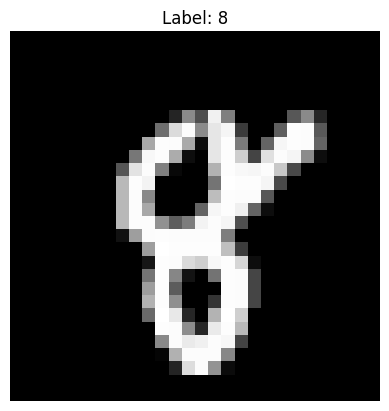

In [118]:
#vediamo un'immagine d'esempio
#dobbiamo togliere appiattimento
import random
idx =  random.randint(0, 59999)
# idx =  146
image = x_train[idx].reshape(28, 28)  # Ripristina la forma 28x28

# Mostra l'immagine
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y_train[idx]}")  # Mostra anche l'etichetta corretta
plt.axis('off')
plt.show()


In [119]:
# Normalizzazione
x_train = x_train / 255.0
x_test = x_test / 255.0

# Appiattimento manuale
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encoding delle etichette
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Modello feedforward
model = Sequential()
model.add(Input(shape=(784,)))              # Input layer per immagini 28x28 appiattite
model.add(Dense(128, activation='relu'))    # Primo hidden layer
model.add(Dense(64, activation='relu'))     # Secondo hidden layer
model.add(Dense(10, activation='softmax'))  # Output layer per classificazione a 10 classi (es. MNIST)

# Compilazione e training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 935us/step - accuracy: 0.8878 - loss: 0.3878 - val_accuracy: 0.9631 - val_loss: 0.1241
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9694 - loss: 0.1021 - val_accuracy: 0.9736 - val_loss: 0.0863
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 922us/step - accuracy: 0.9797 - loss: 0.0652 - val_accuracy: 0.9743 - val_loss: 0.0815
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step - accuracy: 0.9847 - loss: 0.0497 - val_accuracy: 0.9744 - val_loss: 0.0836
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1000us/step - accuracy: 0.9876 - loss: 0.0362 - val_accuracy: 0.9762 - val_loss: 0.0835


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step


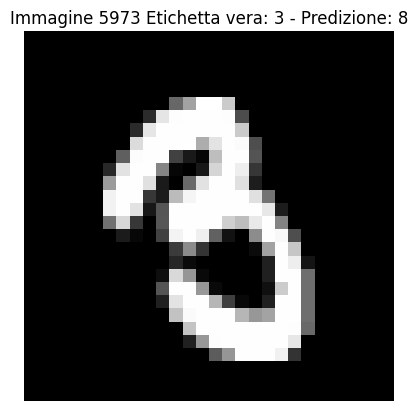

In [121]:
# La rete ha completato il training, ora facciamo le predizioni sul test set
# y_pred avrà shape (10000, 10), cioè 10.000 esempi e 10 probabilità (una per ogni classe)
y_pred = model.predict(x_test)

# Stampa le probabilità di output della rete per tutti i test sample (opzionale, spesso lo si commenta)
#print(y_pred)


# Esempio casuale prendo un campione casuale
# vedere 5973 campione per un 8 che pare un 3
idx = 5973#random.randint(0, 9999)
# Prendiamo l'immagine corrispondente e la rimodelliamo a 28x28 pixel per visualizzarla
image = x_test[idx].reshape(28, 28)

# Etichetta vera (convertendo da one-hot a numero di classe)
label = y_test[idx].argmax()

# Etichetta predetta (classe con probabilità più alta)
label_pred = y_pred[idx].argmax()

# Visualizzazione dell'immagine con etichette
plt.imshow(image, cmap='gray')
plt.title(f"Immagine {idx} Etichetta vera: {label} - Predizione: {label_pred}")
plt.axis('off')
plt.show()



CON convolution

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Caricamento dati
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizzazione e reshape in formato 2D
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# One-hot encoding delle etichette
# o si lascia così e uso sparse cross entropy loss
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Modello CNN
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
# prova prima con 32 filtri poi con 64
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compilazione e training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9054 - loss: 0.3148 - val_accuracy: 0.9771 - val_loss: 0.0696
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9837 - loss: 0.0529 - val_accuracy: 0.9849 - val_loss: 0.0482
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9836 - val_loss: 0.0498
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9827 - val_loss: 0.0525
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9954 - loss: 0.0143 - val_accuracy: 0.9854 - val_loss: 0.0480


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


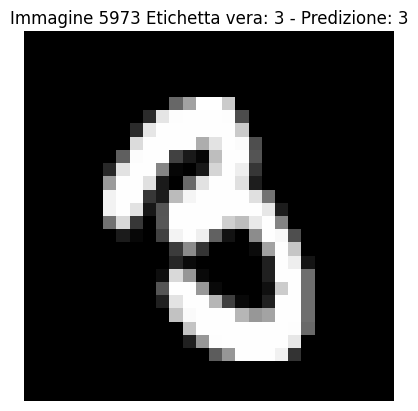

In [115]:
# La rete ha completato il training, ora facciamo le predizioni sul test set
# y_pred avrà shape (10000, 10), cioè 10.000 esempi e 10 probabilità (una per ogni classe)
y_pred = model.predict(x_test)

# Stampa le probabilità di output della rete per tutti i test sample (opzionale, spesso lo si commenta)
#print(y_pred)


# Esempio casuale prendo un campione casuale
# vedere 5973 campione per un 8 che pare un 3
idx = 5973#random.randint(0, 9999)
# Prendiamo l'immagine corrispondente e la rimodelliamo a 28x28 pixel per visualizzarla
image = x_test[idx].reshape(28, 28)

# Etichetta vera (convertendo da one-hot a numero di classe)
label = y_test[idx].argmax()

# Etichetta predetta (classe con probabilità più alta)
label_pred = y_pred[idx].argmax()

# Visualizzazione dell'immagine con etichette
plt.imshow(image, cmap='gray')
plt.title(f"Immagine {idx} Etichetta vera: {label} - Predizione: {label_pred}")
plt.axis('off')
plt.show()
